In [1]:
import numpy as np
import os
import pandas as pd
import xarray as xr
from glob import glob
import matplotlib.pyplot as plt
import itertools as it
from scipy.stats import linregress
from matplotlib.cm import get_cmap
from utils.constants import chamber_levels_complete
import matplotlib.ticker as ticker
import itertools as it
from matplotlib import rcParams


rcParams['font.size'] = 16
rcParams['axes.titlesize'] = 16

prefix_list = ['20231113_4','20240311'] # , '20240316_2']
prefix_names = ['Default', '+ Roots uptake'] # , '+ Roots uptake + phenology']
pft_names = ['Spruce', 'Tamarack', 'Shrub']

outdir = os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output', 'extract')

def fit_line(x, y):
    filt = ~np.isnan(x) & ~np.isnan(y)
    x = x[filt]
    y = y[filt]

    if sum(filt) == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    res = linregress(x, y)
    xnew = np.linspace(x.min(), x.max(), 3)
    ynew = res.slope * xnew + res.intercept
    r2 = res.rvalue**2  # coefficient of determination
    return xnew, ynew, res.slope, res.intercept, r2


# Read the data from `extract_ts_genvars.py`

Generate a growing season time series and an annual collection

In [2]:
collection_gs = {}
collection_annual = {}

for prefix in prefix_list:
    temp_data = pd.read_csv(os.path.join(outdir, prefix, 'analysis_ts.csv'),
                                         header = [0, 1, 2, 3], index_col = 0, parse_dates=True)

    # restrict BTRAN & ZWT to growing season
    for col in temp_data.columns:
        if col[1] in ['BTRAN','ZWT']:
            temp_data.loc[(temp_data.index.month < 5) | (temp_data.index.month > 10), col] = np.nan

    # ratio of total nutrient uptake to AVAILC

    
    # average hummock and hollow, resample to annual
    temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1
        ).apply(lambda df: df.iloc[:,0] * 0.64 + df.iloc[:,1] * 0.36)

    filt = (temp_data.index.month >= 5) & (temp_data.index.month <= 10)
    collection_gs[prefix] = temp_data.loc[filt, :]

    temp_annual = temp_data.resample('1Y').mean()
    temp_annual.index = temp_annual.index.year
    temp_annual.columns = temp_annual.columns.reorder_levels(['variable', 'pft', 'plot'])
    temp_annual = temp_annual.stack()
    collection_annual[prefix] = temp_data

/tmp/ipykernel_2427074/1680606629.py:12: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1
/tmp/ipykernel_2427074/1680606629.py:12: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data = temp_data.groupby(['plot','variable','pft'], axis = 1


In [69]:
chamber_levels_complete

{'04': [4.5, 500],
 '06': [0, 0],
 '08': [6.75, 0],
 '10': [9, 500],
 '11': [2.25, 500],
 '13': [4.5, 0],
 '16': [6.75, 500],
 '17': [9, 0],
 '19': [0, 500],
 '20': [2.25, 0],
 '07': [0, 0]}

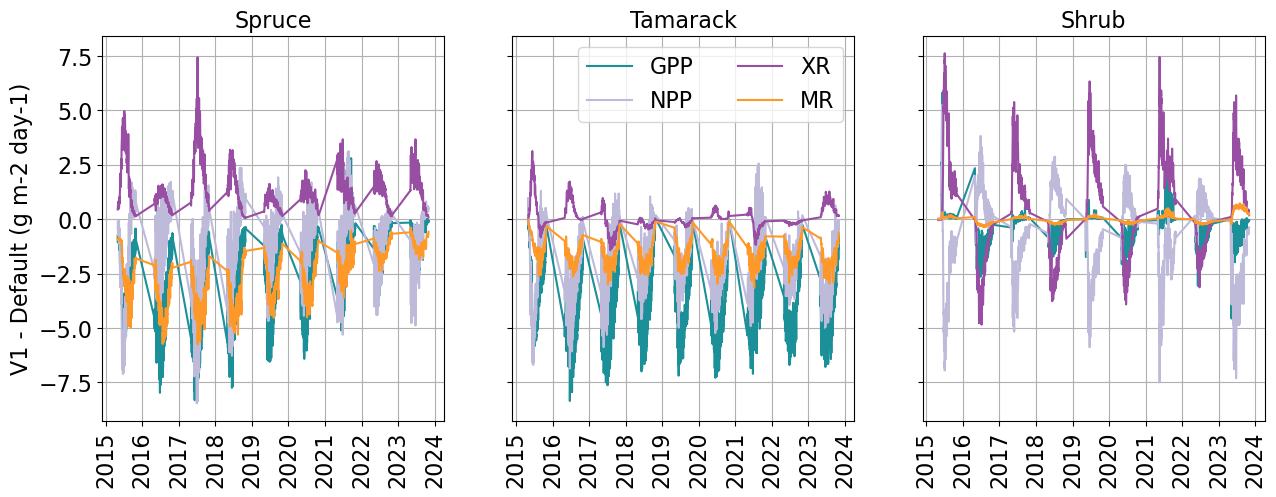

In [179]:
color_list = ['#1c9099', '#bebada', '#984ea3', '#fe9929']

fig, axes = plt.subplots(1, 3, figsize = (15, 5), sharex = True, sharey = True)
plot = '10'
for i, (pft,name) in enumerate(zip(['2','3','11'],['Spruce','Tamarack','Shrub'])):
    ax = axes.flat[i]
    for j, var in enumerate(['GPP', 'NPP', 'XR', 'MR']):
        default = collection_gs['20231113_4'].loc[:, (plot, var, pft)] * 86400
        uptake = collection_gs['20240311'].loc[:, (plot, var, pft)] * 86400
        h = ax.plot(default.index, uptake - default, label = var, color = color_list[j])
        ax.grid(True)
        plt.setp(ax.get_xticklabels(), rotation = 90)
        ax.set_title(name)
    if i == 0:
        ax.set_ylabel(f'V1 - Default (g m-2 day-1)')
    if i == 1:
        ax.legend(ncol = 2)

In [ ]:
color_list = ['#1c9099', '#bebada', '#984ea3', '#fe9929']

fig, axes = plt.subplots(1, 3, figsize = (15, 5), sharex = True, sharey = True)
plot = '10'
for i, (pft,name) in enumerate(zip(['2','3','11'],['Spruce','Tamarack','Shrub'])):
    ax = axes.flat[i]
    for j, var in enumerate(['GPP', 'NPP', 'XR', 'MR']):
        default = collection_gs['20231113_4'].loc[:, (plot, var, pft)] * 86400
        uptake = collection_gs['20240311'].loc[:, (plot, var, pft)] * 86400
        h = ax.plot(default.index, uptake - default, label = var, color = color_list[j])
        ax.grid(True)
        plt.setp(ax.get_xticklabels(), rotation = 90)
        ax.set_title(name)
    if i == 0:
        ax.set_ylabel(f'V1 - Default (g m-2 day-1)')
    if i == 1:
        ax.legend(ncol = 2)

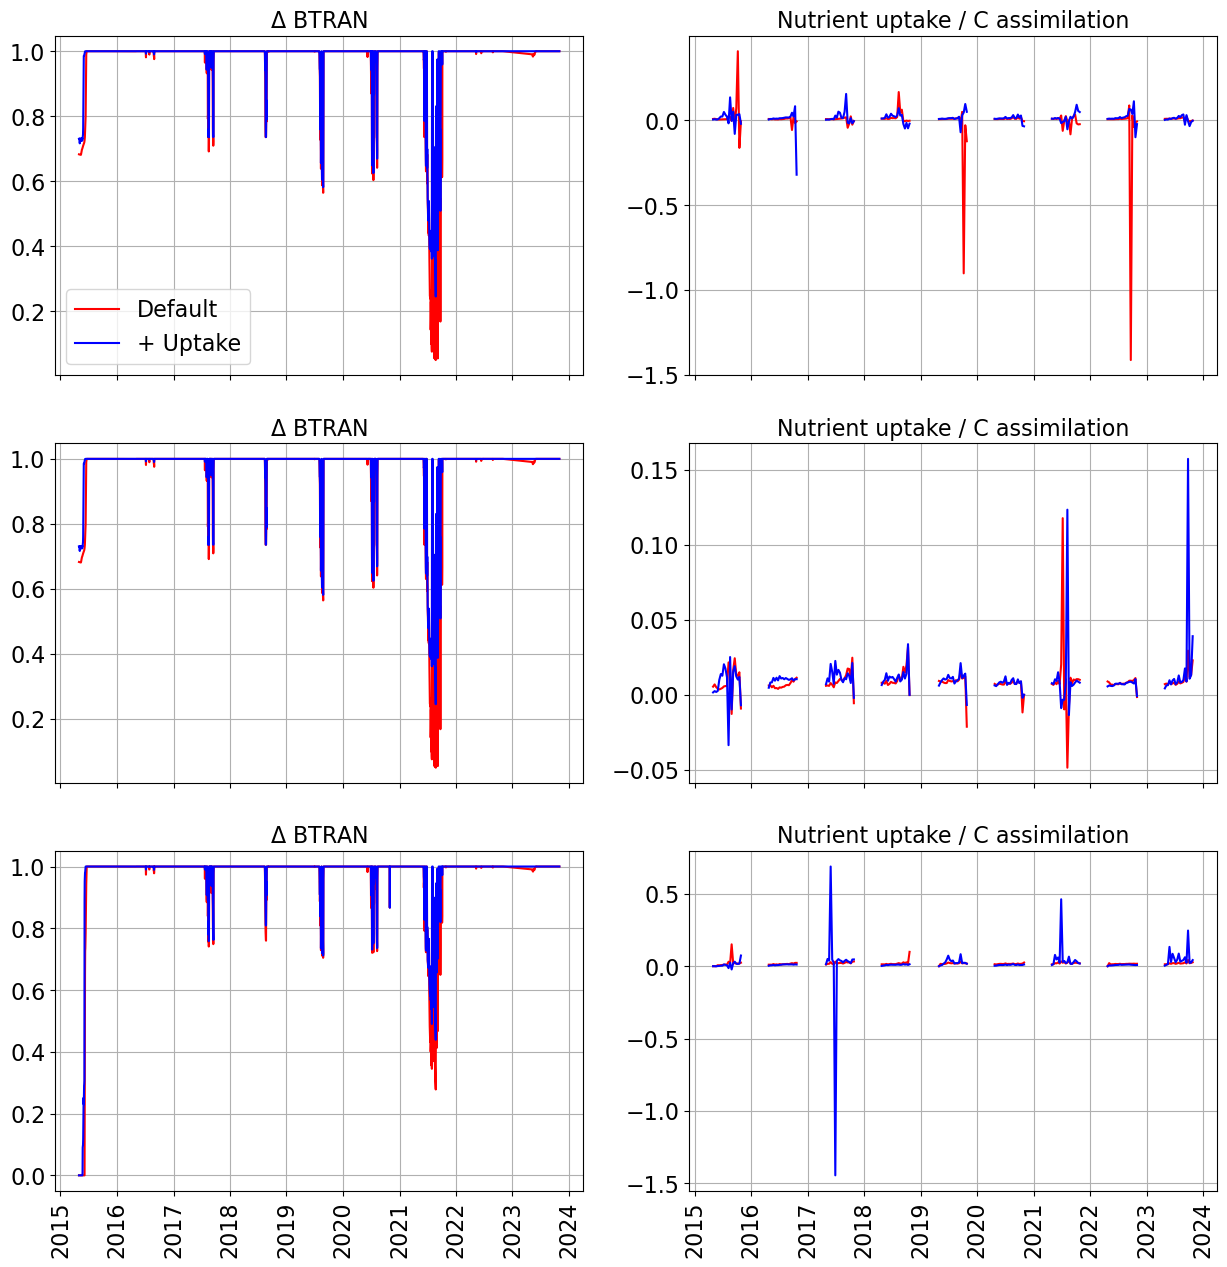

In [149]:
diff = collection_gs['20240311'] - collection_gs['20231113_4']

fig, axes = plt.subplots(3, 2, figsize = (15, 15), sharex = True)
plot = '10'
zwt = diff.loc[:, (plot, 'ZWT', '0')]
tbot = diff.loc[:, (plot, 'TBOT', '0')]
for i, pft in enumerate(['2','3','11']):

    # BTRAN
    #ax = axes[i, 0]
    #cpool = collection_gs['20231113_4'].loc[:, (plot, 'BTRAN', pft)]
    #h = ax.plot(cpool.index, cpool, color = 'r', label = 'Default')
    #cpool = collection_gs['20240311'].loc[:, (plot, 'BTRAN', pft)]
    #h = ax.plot(cpool.index, cpool, color = 'b', label = '+ Uptake')
    #ax.set_title('$\Delta$ BTRAN')
    #ax.grid(True)
    #plt.setp(ax.get_xticklabels(), rotation = 90)
    #if i == 0:
    #    ax.legend()

    # water table depth
    #ax = axes[i, 1]
    #cpool = collection_gs['20231113_4'].loc[:, (plot, 'ZWT', '0')]
    #h = ax.plot(cpool.index, cpool, color = 'r')
    #cpool = collection_gs['20240311'].loc[:, (plot, 'ZWT', '0')]
    #h = ax.plot(cpool.index, cpool, color = 'b')
    #ax.set_title('Water Table Depth (m)')
    #ax.grid(True)
    #plt.setp(ax.get_xticklabels(), rotation = 90)

    # soil moisture
    # ax = axes[i, 2]
    # cpool = collection_gs['20231113_4'].loc[:, (plot, 'H2OSOI_ROOTFR', pft)]
    # h = ax.plot(cpool.index, cpool, color = 'r')
    # cpool = collection_gs['20240311'].loc[:, (plot, 'H2OSOI_ROOTFR', pft)]
    # h = ax.plot(cpool.index, cpool, color = 'b')
    # ax.set_title('Soil water (m3 m-3)')
    # ax.grid(True)
    # plt.setp(ax.get_xticklabels(), rotation = 90)

    # Nutrient uptake/C assimilation
    ax = axes[i, 1]

    smin_uptake = collection_gs['20231113_4'].loc[:, (plot, 'SMINN_TO_NPOOL', pft)]
    cdemand = collection_gs['20231113_4'].loc[:, (plot, 'GPP', pft)] - collection_gs['20231113_4'].loc[:, (plot, 'MR', pft)] - collection_gs['20231113_4'].loc[:, (plot, 'XR', pft)]

    cpool = smin_uptake.resample('10D').mean() / cdemand.resample('10D').mean()
    h = ax.plot(cpool.index, cpool, color = 'r')

    smin_uptake = collection_gs['20240311'].loc[:, (plot, 'FUNGI_SOM_TO_NPOOL', pft)] + collection_gs['20240311'].loc[:, (plot, 'SMINN_TO_NPOOL', pft)]
    cdemand = collection_gs['20240311'].loc[:, (plot, 'GPP', pft)] - collection_gs['20240311'].loc[:, (plot, 'MR', pft)] - collection_gs['20240311'].loc[:, (plot, 'XR', pft)]
    cpool = smin_uptake.resample('10D').mean() / cdemand.resample('10D').mean()

    h = ax.plot(cpool.index, cpool, color = 'b')
    ax.set_title('Nutrient uptake / C assimilation')
    ax.grid(True)
    plt.setp(ax.get_xticklabels(), rotation = 90)